In [1]:
import numpy as np
import matplotlib.pyplot as plt

**Dataset**

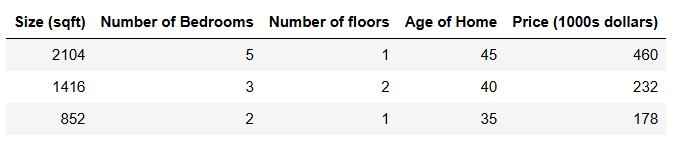

In [37]:
X_train = np.array([
    [2104, 5, 1, 45],
    [1416, 3, 2, 40],
    [852, 2, 1, 35]
])

y_train = np.array([460, 232, 178])

print(X_train)
print(X_train.shape)
print(y_train)
print(y_train.shape)

[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
(3, 4)
[460 232 178]
(3,)


In [3]:
# Single prediction

def single_loop_prediction(x, w, b):
  pred = 0
  m = x.shape[0]

  for i in range(m):
    f_wb = w[i] * x[i]
    pred = pred + f_wb
  prediction = pred + b
  return prediction


In [4]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])

In [5]:
# # take a row from x_train

p = single_loop_prediction(X_train, w_init, b_init)
print(p)

[-17299.1111338     736.67846672    769.71968244   -314.6694346 ]


In [6]:
# take a row from x_train
x_1 = X_train[0]
print(x_1)
print(x_1.shape)

[2104    5    1   45]
(4,)


In [7]:
result = single_loop_prediction(x_1, w_init, b_init)
print(result)

459.9999976194083


In [8]:
# now using dot product

def prediction(x,w,b):
  pred = np.dot(w,x) + b
  return pred

In [9]:
result = prediction(x_1, w_init, b_init)
print(result)

459.9999976194083


Cost Calculation

In [36]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


In [38]:
def compute_cost(X,y,w,b):
  cost = 0
  m = X.shape[0]
  for i in range(m):
    f_wb_i = np.dot(w , X[i]) + b
    j_wb = (f_wb_i - y[i]) ** 2
    cost = cost + j_wb
  cost = cost / (2 * m)
  return cost


In [39]:
calculate_cost = compute_cost(X_train, y_train, w_init, b_init)
print("Cost is: ", calculate_cost)

Cost is:  1.5578904428966628e-12


In [47]:
# Compute gradient descent
def compute_gradient(X, y, w, b):
  m,n = X.shape
  dj_dw = np.zeros((n,))
  dj_db = 0
  for i in range(m):
    f_wb_i = np.dot(w , X[i]) + b
    error = f_wb_i - y[i]
    for j in range(n):
      dj_dw[j] = dj_dw[j] + error * X[i,j]
    dj_db = dj_db + error
  dj_dw = dj_dw / m
  dj_db = dj_db / m
  return dj_dw, dj_db

In [48]:
tmp_dj_dw , tmp_dj_db = compute_gradient(X_train, y_train, w_init, b_init)
print(tmp_dj_db)
print(tmp_dj_db)

-1.6739251501955248e-06
-1.6739251501955248e-06


In [16]:
import copy
import math

In [49]:
# Gradient Descent
def gradient_descent(X, y, w_in , b_in , alpha, iters, gradient_fun, cost_fun):

  b = b_in
  w = copy.deepcopy(w_in)
  j_wb_history = []

  for i in range(iters):

    dj_dw, dj_db = gradient_fun(X, y, w, b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i < 10000:
      j_wb_history.append(cost_fun(X, y, w, b))

    if i % math.ceil(iters / 10) == 0:
      print(f"Iteration: {i:4d}: Cost = {j_wb_history[-1]:8.2f}  ")

  return w, b, j_wb_history

In [50]:
w_initial = np.zeros_like((w_init))
b_initial = 0
alph = 5.0e-7
iterations = 1000

In [60]:
w_final, b_final, cost_history = gradient_descent(X_train, y_train, w_initial, b_initial, alph, iterations, compute_gradient, compute_cost)

print(f"Final b : {b_final:.2f}, Final w: {w_final}")
print("Cost History" , cost_history[:100])

Iteration:    0: Cost =  2529.46  
Iteration:  100: Cost =   695.99  
Iteration:  200: Cost =   694.92  
Iteration:  300: Cost =   693.86  
Iteration:  400: Cost =   692.81  
Iteration:  500: Cost =   691.77  
Iteration:  600: Cost =   690.73  
Iteration:  700: Cost =   689.71  
Iteration:  800: Cost =   688.70  
Iteration:  900: Cost =   687.69  
Final b : -0.00, Final w: [ 0.20396569  0.00374919 -0.0112487  -0.0658614 ]
Cost History [np.float64(2529.4629522316304), np.float64(765.8336829952988), np.float64(699.6290280210446), np.float64(697.1337425623095), np.float64(697.0296591788104), np.float64(697.0153256006653), np.float64(697.0043615139087), np.float64(696.9935248096691), np.float64(696.9826938019223), np.float64(696.9718639233548), np.float64(696.9610350024587), np.float64(696.9502070327148), np.float64(696.939380013799), np.float64(696.9285539456151), np.float64(696.9177288280792), np.float64(696.9069046611058), np.float64(696.8960814446137), np.float64(696.8852591785139), np

In [61]:
m,_ = X_train.shape
for i in range(m):
  print(f"Prediction: {np.dot(w_final , X_train[i]) + b_final:.2f} , Target Value: {y_train[i]}")


Prediction: 426.19 , Target Value: 460
Prediction: 286.17 , Target Value: 232
Prediction: 171.47 , Target Value: 178


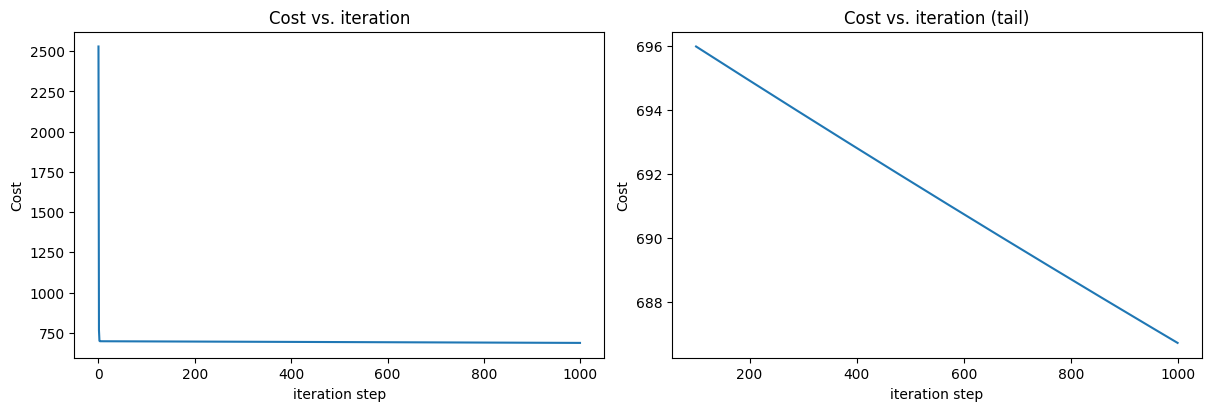

In [62]:
# plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(cost_history)
ax2.plot(100 + np.arange(len(cost_history[100:])), cost_history[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step')
plt.show()